In [ ]:
## Fully torch supported Can run in cpu Bad kink on the lower half##

In [1]:

import numpy as np 
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]=T[1] # Left boundary
    T[-1]=T[-2]**2/max(T[-3],1e-40) # Right boundary

def solve_two_layer_FTCS(k1, k2, z_dis,Pda,Lz,nz,tf,device):
    # Construct numerical grid
    dz = Lz/nz; z = torch.arange(-0.5, nz+1, device=device)*dz
    # Finite volume, *** z_dis is at a cell boundary ***
    # need one more point at each end, *** size of z = (nz+2) ***

    # Make sure we reach tf in integer number of setps
    dt = 0.5*(dz**2)/max(k1, k2) # need to include k1 and k2 in dt
    nt = int(np.ceil(tf/dt)); dt = tf/nt # need to update dt 
    print(f'nz = {nz}, nt = {nt}; alignment of nt*dt with tf: err = {nt*dt-tf}')
    
    # Find index m such that z[m+1] > z_dis
    m = torch.searchsorted(z, z_dis, right=True).item()-1
    # no need to move a scalar between gpu and cpu?
    # check z[m+1/2]=z_dis?
    print(f'm = {m}, alignment of z[m+1/2] with z_dis: err = {z[m]+0.5*dz-z_dis}')
    
    # Harmonic mean of k at z_dis
    k_interface = 2 * k1 * k2 / (k1 + k2)
    # Precompute kh (effective k at half grid point z_{j+1/2})
    kh = torch.where(z[:-1] < z_dis, k1, k2); kh[m] = k_interface
    # *** size of kh = (nz+1) ***
    # Pytorch will automatically use the device and dtype of z
    
    # Source at internal points, *** size of source = nz ***
    source = Pda * torch.exp(-z[1:-1])

    # Need to pre-allocate T and J
    T = torch.zeros(nz+2, device=device) # size of T = nz+2
    Jh = torch.zeros(nz+1, device=device) # size of k = nz+1
    
    # advance in time steps
    for tstep in range(nt):
        # FTCS update
        set_BCs(T) # start each step by enforcing BCs
        Jh = -kh * (T[1:]-T[:-1])/dz # Flux 
        T[1:-1] = T[1:-1] + dt/dz*(Jh[:-1] - Jh[1:])+dt*source
    set_BCs(T) # at the end enforce BC again
    return z, T



In [2]:
import torch

# ============================================================
# Not-a-knot cubic spline (uniform grid)
# ============================================================
def cubic_spline_not_a_knot(z, T):
    N = len(z)
    h = z[1] - z[0]
    device, dtype = z.device, z.dtype

    A = torch.zeros((N, N), device=device, dtype=dtype)
    rhs = torch.zeros(N, device=device, dtype=dtype)

    for i in range(1, N-1):
        A[i, i-1] = 1.0
        A[i, i]   = 4.0
        A[i, i+1] = 1.0
        rhs[i] = 6.0 * (T[i+1] - 2*T[i] + T[i-1]) / h**2

    # not-a-knot BCs
    A[0,0] = 1.0; A[0,1] = -1.0
    A[-1,-1] = 1.0; A[-1,-2] = -1.0

    return torch.linalg.solve(A, rhs)

# ============================================================
# Cubic spline evaluation
# ============================================================
def spline_eval(z, T, M, x):
    h = z[1] - z[0]
    i = torch.searchsorted(z, x) - 1
    i = torch.clamp(i, 0, len(z)-2)

    zi, zi1 = z[i], z[i+1]
    Ti, Ti1 = T[i], T[i+1]
    Mi, Mi1 = M[i], M[i+1]

    return (
        Mi*(zi1-x)**3/(6*h)
        + Mi1*(x-zi)**3/(6*h)
        + (Ti - Mi*h**2/6)*(zi1-x)/h
        + (Ti1 - Mi1*h**2/6)*(x-zi)/h
    )

# ============================================================
# TWO SPLINES with C¹ CONTINUITY (k-weighted)
# ============================================================
def map_2_grid(z, T, k1, k2, z_dis):
    device, dtype = z.device, z.dtype
    dz = z[1] - z[0]

    m = int((torch.searchsorted(z, z_dis, right=True) - 1).item())

    # Interface temperature (4th-order)
    T_dis = (9*(k1*T[m] + k2*T[m+1]) - (k1*T[m-1] + k2*T[m+2])) / (8*(k1 + k2))

    # Left/right slopes
    dT_minus = (T[m] - T[m-1]) / dz
    dT_plus  = (T[m+1] - T[m]) / dz

    # k-weighted common slope (C¹)
    dT_star = (k1*dT_minus + k2*dT_plus) / (k1 + k2)

    z_dis_t = torch.tensor([z_dis], device=device, dtype=dtype)

    # ----- left spline -----
    zL = torch.cat([z[:m+1], z_dis_t])
    TL = torch.cat([T[:m+1], T_dis.unsqueeze(0)])
    ML = cubic_spline_not_a_knot(zL, TL)

    # ----- right spline -----
    zR = torch.cat([z_dis_t, z[m+1:]])
    TR = torch.cat([T_dis.unsqueeze(0), T[m+1:]])
    MR = cubic_spline_not_a_knot(zR, TR)

    # evaluate on midpoints
    zg = 0.5 * (z[:-1] + z[1:])
    Tg = torch.empty_like(zg)

    for i, x in enumerate(zg):
        if x <= z_dis:
            Tg[i] = spline_eval(zL, TL, ML, x)
        else:
            Tg[i] = spline_eval(zR, TR, MR, x)

    return zg, Tg



In [3]:
start = time.perf_counter()

device='cuda'
k1=1.0; k2=1.0; z_dis=1.0; Pda=1.0; tf=2; Lz=8.0; nz_unit=10; 
nz1=int(Lz)*nz_unit;
z1,T1 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz1,tf,device)
zg1,Tg1 = map_2_grid(z1, T1, k1, k2, z_dis)
#
nz2=nz1*2;
z2,T2 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz2,tf,device)
zg2,Tg2 = map_2_grid(z2, T2, k1, k2, z_dis)
#
nz3=nz2*2;
z3,T3 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz3,tf,device)
zg3,Tg3 = map_2_grid(z3, T3, k1, k2, z_dis)
#
nz4=nz3*2;
z4,T4 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz4,tf,device)
zg4,Tg4 = map_2_grid(z4, T4, k1, k2, z_dis)
#
# Error estimates
er_g1 = (Tg1-Tg2[::2])*4/3
er_g2 = (Tg2-Tg3[::2])*4/3
er_g3 = (Tg3-Tg4[::2])*4/3

end = time.perf_counter()
print(f'device = {device}; elapsed time = {end-start:.3f} seconds')


nz = 80, nt = 400; alignment of nt*dt with tf: err = 0.0
m = 10, alignment of z[m+1/2] with z_dis: err = 0.0
nz = 160, nt = 1600; alignment of nt*dt with tf: err = 0.0
m = 20, alignment of z[m+1/2] with z_dis: err = 0.0
nz = 320, nt = 6400; alignment of nt*dt with tf: err = 0.0
m = 40, alignment of z[m+1/2] with z_dis: err = 0.0
nz = 640, nt = 25600; alignment of nt*dt with tf: err = 0.0
m = 80, alignment of z[m+1/2] with z_dis: err = 0.0
device = cuda; elapsed time = 6.818 seconds


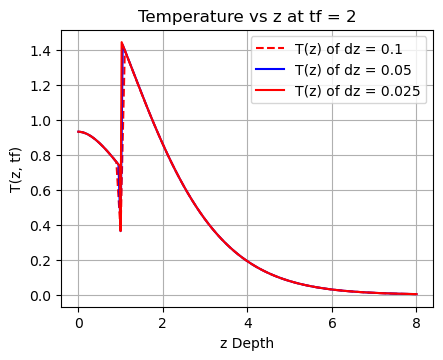

In [4]:
fig1 = plt.figure(figsize=(4.8,3.6))
plt.clf()
plt.plot(zg1.cpu(), Tg1.cpu(), 'r--', label=f'T(z) of dz = {Lz/nz1}')
plt.plot(zg2.cpu(), Tg2.cpu(), 'b-', label=f'T(z) of dz = {Lz/nz2}')
plt.plot(zg3.cpu(), Tg3.cpu(), 'r-', label=f'T(z) of dz = {Lz/nz3}')
plt.xlabel('z Depth')
plt.ylabel(f'T(z, tf)')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.title(f'Temperature vs z at tf = {tf}')
plt.legend()
plt.grid(True)
# plt.savefig('compB.pdf',bbox_inches='tight')
plt.show()

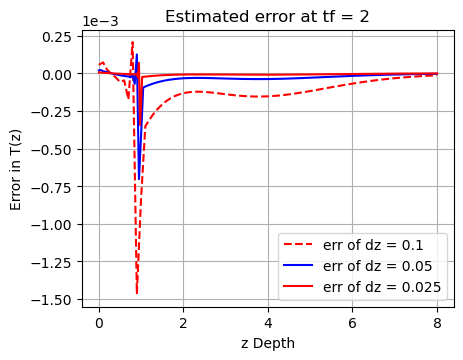

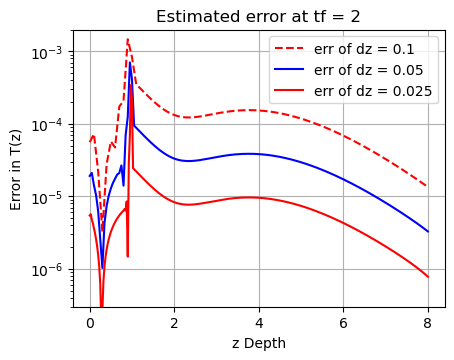

In [5]:

fig2A = plt.figure(figsize=(4.8,3.6))
plt.clf()
plt.plot(zg1.cpu(), er_g1.cpu(), 'r--', label=f'err of dz = {Lz/nz1}')
plt.plot(zg2.cpu(), er_g2.cpu(), 'b-', label=f'err of dz = {Lz/nz2}')
plt.plot(zg3.cpu(), er_g3.cpu(), 'r-', label=f'err of dz = {Lz/nz3}')
plt.xlabel('z Depth')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.ylabel(f'Error in T(z)')
plt.title(f'Estimated error at tf = {tf}')
plt.legend()
plt.grid(True)
# plt.savefig('compB.pdf',bbox_inches='tight')
plt.show()

fig2B= plt.figure(figsize=(4.8,3.6))
plt.clf()
plt.semilogy(zg1.cpu(), torch.abs(er_g1).cpu(), 'r--', label=f'err of dz = {Lz/nz1}')
plt.semilogy(zg2.cpu(), torch.abs(er_g2).cpu(), 'b-', label=f'err of dz = {Lz/nz2}')
plt.semilogy(zg3.cpu(), torch.abs(er_g3).cpu(), 'r-', label=f'err of dz = {Lz/nz3}')
plt.xlabel('z Depth')
plt.ylabel(f'Error in T(z)'); plt.ylim(3e-7,2e-3)
plt.title(f'Estimated error at tf = {tf}')
plt.legend()
plt.grid(True)
# plt.savefig('compB.pdf',bbox_inches='tight')
plt.show()
